#### Construção e limpeza dos dados (Data Preparation Initial)

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# carregar os dados
df = pd.read_csv("AB_NYC_2019.csv")

# remoção das colunas 'name', 'host_name' e 'last_review'
colunas_para_remover = ["name", "host_name", "last_review"]
colunas_existentes = df.columns
remover_colunas = [coluna for coluna in colunas_para_remover if coluna in colunas_existentes]
df = df.drop(columns=remover_colunas)

# substituição de NA's na coluna 'reviews_per_month' por 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# alteração da coluna 'room_type'
df = pd.get_dummies(df, columns=['room_type'])
coluna_dummy = [col for col in df.columns if 'room_type' in col]
df[coluna_dummy] = df[coluna_dummy].astype(int)

# alteração da coluna 'neighbourhood_group'
freq_ng = df["neighbourhood_group"].value_counts()
idf_ng = np.log(len(df) / (freq_ng + 1))
df["neighbourhood_group"] = df["neighbourhood_group"].map(idf_ng).round(5)

# alteração da coluna 'neighbourhood'
freq_n = df["neighbourhood"].value_counts()
idf_n = np.log(len(df) / (freq_n + 1))
df["neighbourhood"] = df["neighbourhood"].map(idf_n).round(5)

# novo csv
df.to_csv("Airbnb_NYC_2019.csv", index=False)

In [3]:
df = pd.read_csv("Airbnb_NYC_2019.csv")

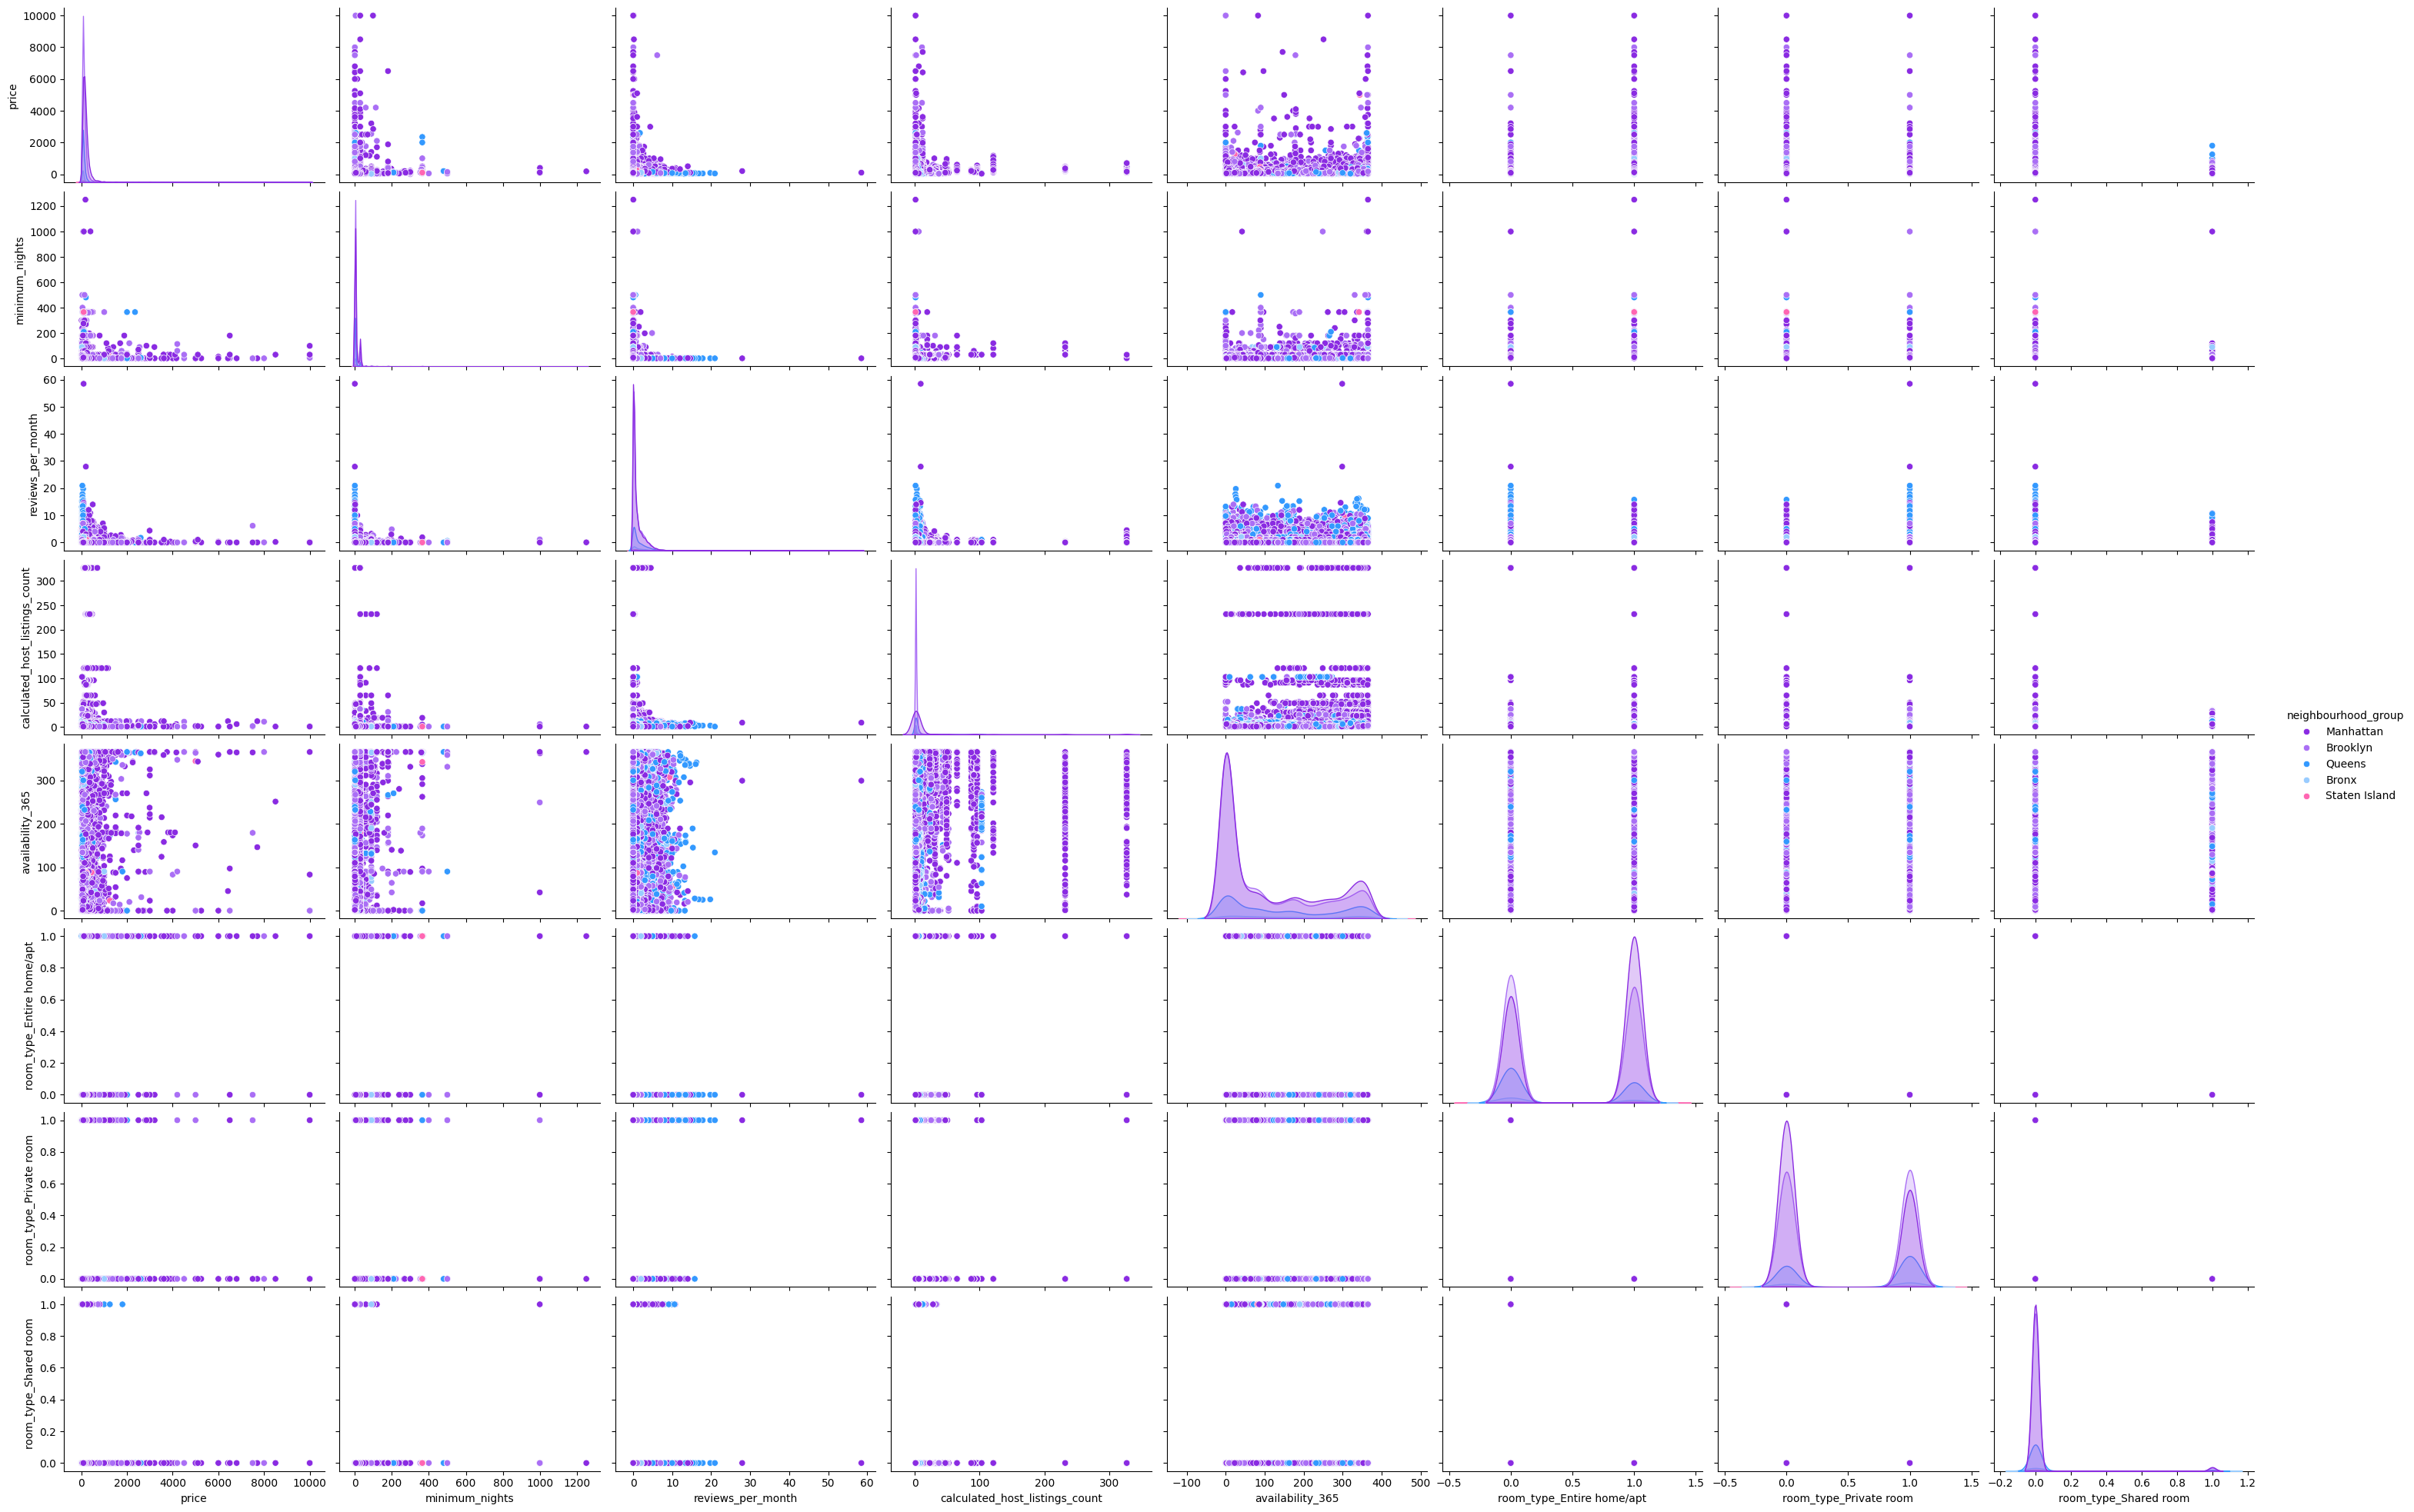

In [4]:
columns = ["price", "minimum_nights", "reviews_per_month", "calculated_host_listings_count", "availability_365", "neighbourhood_group", "room_type_Entire home/apt", "room_type_Private room", "room_type_Shared room"]
palette_custom = {
    0.81412: "#8A2BE2",
    0.88871: "#AA6FF5",
    2.15502: "#3399FF", 
    3.80166: "#99CCFF", 
    4.87317: "#FF66B2"
    }
names_neighbourhood_group = {
    0.81412: "Manhattan",
    0.88871: "Brooklyn",
    2.15502: "Queens",
    3.80166: "Bronx",
    4.87317: "Staten Island"
    }
g = sns.pairplot(df[columns], hue="neighbourhood_group", aspect=1.5, palette=palette_custom)
for t, l in zip(g._legend.texts, g._legend.texts):
    val = float(t.get_text())
    t.set_text(names_neighbourhood_group.get(val, val))
plt.show()